In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import joblib

# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)

Project root: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle
Processed directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed
Models directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\models


In [2]:
monitoring_reference_path = (PROCESSED_DIR / "monitoring_reference.pkl")

monitoring_reference = pd.read_pickle(monitoring_reference_path)

print("Monitoring reference loaded successfully.")
print("Shape:", monitoring_reference.shape)
print(
    "Unique customers:",
    monitoring_reference["Customer_ID"].nunique()
)

Monitoring reference loaded successfully.
Shape: (70000, 36)
Unique customers: 8750


In [3]:
model = joblib.load(MODELS_DIR / "xgboost_credit_score.pkl")

preprocessor = joblib.load(MODELS_DIR / "preprocessor.pkl")

feature_names = joblib.load(PROCESSED_DIR / "feature_names.pkl")

print("Model:", type(model).__name__)
print("Number of processed features:", len(feature_names))
print("Classes:", model.classes_)

C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


Model: XGBClassifier
Number of processed features: 61
Classes: ['Good' 'Poor' 'Standard']


In [4]:
numeric_features = list(preprocessor.transformers_[0][2])

categorical_features = list(preprocessor.transformers_[1][2])

monitoring_features = (numeric_features + categorical_features)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total monitoring features:", len(monitoring_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features: 26
Categorical features: 5
Total monitoring features: 31

Numeric features:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months', 'Num_Loan_Types', 'Has_auto_loan', 'Has_credit_builder_loan', 'Has_personal_loan', 'Has_home_equity_loan', 'Has_mortgage_loan', 'Has_student_loan', 'Has_debt_consolidation_loan', 'Has_payday_loan']

Categorical features:
['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [5]:
# first monitoring check
reference_features = monitoring_reference[monitoring_features].copy()

print("Reference monitoring data shape:")
print(reference_features.shape)

print("\nMissing values:")
print(reference_features.isna().sum().sum())

print("\nNumeric features:")
print(reference_features[numeric_features].describe().T)

Reference monitoring data shape:
(70000, 31)

Missing values:
58759

Numeric features:
                               count          mean           std  \
Age                          64129.0  3.445357e+01  1.011464e+01   
Annual_Income                70000.0  1.759342e+05  1.427785e+06   
Monthly_Inhand_Salary        59522.0  4.208866e+03  3.197893e+03   
Num_Bank_Accounts            70000.0  1.739986e+01  1.195191e+02   
Num_Credit_Card              70000.0  2.290481e+01  1.307195e+02   
Interest_Rate                70000.0  7.191010e+01  4.626982e+02   
Num_of_Loan                  70000.0  2.939714e+00  6.170223e+01   
Delay_from_due_date          70000.0  2.103370e+01  1.479752e+01   
Num_of_Delayed_Payment       65144.0  3.162661e+01  2.322391e+02   
Changed_Credit_Limit         68524.0  1.039684e+01  6.797928e+00   
Num_Credit_Inquiries         68620.0  2.831246e+01  1.964339e+02   
Outstanding_Debt             70000.0  1.422906e+03  1.154195e+03   
Credit_Utilization_Ratio     

In [6]:
# Implement Population Stability Index (PSI)
def calculate_psi(reference, current, bins=10):
    """
    Calculate Population Stability Index (PSI)
    between a reference and current distribution.
    """

    reference = pd.Series(reference).dropna()
    current = pd.Series(current).dropna()

    if len(reference) == 0 or len(current) == 0:
        return np.nan

    # Constant feature
    if reference.nunique() <= 1:
        return 0.0

    # Quantile-based bins from reference data
    breakpoints = np.percentile(
        reference,
        np.linspace(0, 100, bins + 1)
    )

    breakpoints = np.unique(breakpoints)

    # Not enough unique values to create bins
    if len(breakpoints) < 3:
        return 0.0

    # Extend outer boundaries so future extreme values
    # are still included
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    reference_binned = pd.cut(
        reference,
        bins=breakpoints,
        include_lowest=True
    )

    current_binned = pd.cut(
        current,
        bins=breakpoints,
        include_lowest=True
    )

    reference_dist = (
        reference_binned
        .value_counts(normalize=True, sort=False)
    )

    current_dist = (
        current_binned
        .value_counts(normalize=True, sort=False)
    )

    # Small epsilon prevents log(0)
    epsilon = 1e-6

    reference_dist = reference_dist + epsilon
    current_dist = current_dist + epsilon

    psi = np.sum(
        (current_dist - reference_dist)
        * np.log(current_dist / reference_dist)
    )

    return float(psi)

In [7]:
test_psi = calculate_psi(
    monitoring_reference["Annual_Income"],
    monitoring_reference["Annual_Income"]
)

print("Self-comparison PSI:", test_psi)

Self-comparison PSI: 0.0


In [8]:
# Create stable production data
# Reproducible production simulation
np.random.seed(42)

stable_production = monitoring_reference[
    monitoring_features
].sample(
    n=15000,
    random_state=42
).reset_index(drop=True)

print("Stable production shape:", stable_production.shape)
print("Missing values:", stable_production.isna().sum().sum())

Stable production shape: (15000, 31)
Missing values: 12673


In [9]:
#drifted production dataset
drifted_production = stable_production.copy()

# --------------------------------------------------
# 1. Increase financial burden
# --------------------------------------------------

drifted_production["Outstanding_Debt"] = (
    drifted_production["Outstanding_Debt"] * 1.40
)

drifted_production["Total_EMI_per_month"] = (
    drifted_production["Total_EMI_per_month"] * 1.30
)

# --------------------------------------------------
# 2. Increase credit inquiries
# --------------------------------------------------

drifted_production["Num_Credit_Inquiries"] = (
    drifted_production["Num_Credit_Inquiries"] * 1.50
)

# --------------------------------------------------
# 3. Increase payment delays
# --------------------------------------------------

drifted_production["Delay_from_due_date"] = (
    drifted_production["Delay_from_due_date"] + 5
)

drifted_production["Num_of_Delayed_Payment"] = (
    drifted_production["Num_of_Delayed_Payment"] * 1.35
)

# --------------------------------------------------
# 4. Simulate more missing Monthly_Inhand_Salary
# --------------------------------------------------

missing_mask = np.random.rand(
    len(drifted_production)
) < 0.25

drifted_production.loc[
    missing_mask,
    "Monthly_Inhand_Salary"
] = np.nan

# --------------------------------------------------
# 5. Change Credit_Mix distribution
# --------------------------------------------------

credit_mix_values = np.random.choice(
    ["Bad", "Standard", "Good"],
    size=len(drifted_production),
    p=[0.50, 0.40, 0.10]
)

drifted_production["Credit_Mix"] = credit_mix_values

# --------------------------------------------------
# 6. Change payment behaviour distribution
# --------------------------------------------------

payment_behaviour_values = np.random.choice(
    [
        "High_spent_Large_value_payments",
        "High_spent_Medium_value_payments",
        "High_spent_Small_value_payments",
        "Low_spent_Large_value_payments",
        "Low_spent_Medium_value_payments",
        "Low_spent_Small_value_payments"
    ],
    size=len(drifted_production),
    p=[0.10, 0.10, 0.10, 0.30, 0.25, 0.15]
)

drifted_production["Payment_Behaviour"] = (
    payment_behaviour_values
)

print("Drifted production shape:", drifted_production.shape)
print(
    "Missing values:",
    drifted_production.isna().sum().sum()
)

Drifted production shape: (15000, 31)
Missing values: 11714


In [10]:
# missingness monitor
def calculate_missingness(data, features):
    """
    Calculate percentage of missing values per feature.
    """
    
    return (
        data[features]
        .isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )


reference_missingness = calculate_missingness(
    monitoring_reference,
    monitoring_features
)

stable_missingness = calculate_missingness(
    stable_production,
    monitoring_features
)

drifted_missingness = calculate_missingness(
    drifted_production,
    monitoring_features
)

missingness_comparison = pd.DataFrame({
    "Reference_%": reference_missingness,
    "Stable_%": stable_missingness,
    "Drifted_%": drifted_missingness
})

missingness_comparison["Stable_Change_pp"] = (
    missingness_comparison["Stable_%"]
    - missingness_comparison["Reference_%"]
)

missingness_comparison["Drifted_Change_pp"] = (
    missingness_comparison["Drifted_%"]
    - missingness_comparison["Reference_%"]
)

missingness_comparison.head(15)

,Reference_%,Stable_%,Drifted_%,Stable_Change_pp,Drifted_Change_pp
Age,8.387143,8.053333,8.053333,-0.333810,-0.333810
Amount_invested_monthly,4.502857,4.706667,4.706667,0.203810,0.203810
Annual_Income,0.000000,0.000000,0.000000,0.000000,0.000000
Changed_Credit_Limit,2.108571,2.206667,2.206667,0.098095,0.098095
Credit_History_Months,9.052857,9.040000,9.040000,-0.012857,-0.012857
Credit_Mix,20.230000,20.033333,0.000000,-0.196667,-20.230000
Credit_Utilization_Ratio,0.000000,0.000000,0.000000,0.000000,0.000000
Delay_from_due_date,0.000000,0.000000,0.000000,0.000000,0.000000
Has_auto_loan,0.000000,0.000000,0.000000,0.000000,0.000000
Has_credit_builder_loan,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
# Numeric Drift: Calculate PSI for all 26 numeric features
def interpret_psi(psi):
    if pd.isna(psi):
        return "Unavailable"
    elif psi < 0.10:
        return "No significant drift"
    elif psi < 0.25:
        return "Moderate drift"
    else:
        return "Significant drift"


def calculate_numeric_drift(
    reference_data,
    current_data,
    numeric_features
):
    
    results = []

    for feature in numeric_features:
        
        psi = calculate_psi(
            reference_data[feature],
            current_data[feature]
        )
        
        results.append({
            "Feature": feature,
            "PSI": psi,
            "Interpretation": interpret_psi(psi)
        })

    return (
        pd.DataFrame(results)
        .sort_values("PSI", ascending=False)
        .reset_index(drop=True)
    )

In [12]:
#Test the stable Population
stable_numeric_drift = calculate_numeric_drift(
    monitoring_reference,
    stable_production,
    numeric_features
)

stable_numeric_drift

,Feature,PSI,Interpretation
0,Num_of_Delayed_Payment,0.001088,No significant drift
1,Changed_Credit_Limit,0.001000,No significant drift
2,Credit_Utilization_Ratio,0.000909,No significant drift
3,Monthly_Inhand_Salary,0.000889,No significant drift
4,Num_Bank_Accounts,0.000830,No significant drift
5,Annual_Income,0.000763,No significant drift
6,Age,0.000546,No significant drift
7,Interest_Rate,0.000545,No significant drift
8,Amount_invested_monthly,0.000507,No significant drift
9,Num_Credit_Inquiries,0.000461,No significant drift


In [13]:
# Test on Drifted Dataset
drifted_numeric_drift = calculate_numeric_drift(
    monitoring_reference,
    drifted_production,
    numeric_features
)

drifted_numeric_drift

,Feature,PSI,Interpretation
0,Num_Credit_Inquiries,2.669338,Significant drift
1,Num_of_Delayed_Payment,0.655966,Significant drift
2,Delay_from_due_date,0.306051,Significant drift
3,Outstanding_Debt,0.232424,Moderate drift
4,Total_EMI_per_month,0.055869,No significant drift
5,Changed_Credit_Limit,0.001000,No significant drift
6,Credit_Utilization_Ratio,0.000909,No significant drift
7,Num_Bank_Accounts,0.000830,No significant drift
8,Annual_Income,0.000763,No significant drift
9,Monthly_Inhand_Salary,0.000713,No significant drift


In [14]:
# Categorical drift - Total Variation Distance
def calculate_tv_distance(reference, current):
    """
    Calculate Total Variation Distance between
    two categorical distributions.
    """

    reference = pd.Series(reference).fillna("__MISSING__")
    current = pd.Series(current).fillna("__MISSING__")

    categories = set(reference.unique()) | set(current.unique())

    reference_dist = (
        reference.value_counts(normalize=True)
        .reindex(categories, fill_value=0)
    )

    current_dist = (
        current.value_counts(normalize=True)
        .reindex(categories, fill_value=0)
    )

    tv_distance = 0.5 * np.abs(
        reference_dist - current_dist
    ).sum()

    return float(tv_distance)


def interpret_tv(tv):
    if pd.isna(tv):
        return "Unavailable"
    elif tv < 0.05:
        return "No significant drift"
    elif tv < 0.10:
        return "Moderate drift"
    else:
        return "Significant drift"


def calculate_categorical_drift(
    reference_data,
    current_data,
    categorical_features
):
    
    results = []

    for feature in categorical_features:
        
        tv = calculate_tv_distance(
            reference_data[feature],
            current_data[feature]
        )
        
        results.append({
            "Feature": feature,
            "TV_Distance": tv,
            "Interpretation": interpret_tv(tv)
        })

    return (
        pd.DataFrame(results)
        .sort_values(
            "TV_Distance",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [15]:
#Test
stable_categorical_drift = calculate_categorical_drift(
    monitoring_reference,
    stable_production,
    categorical_features
)

drifted_categorical_drift = calculate_categorical_drift(
    monitoring_reference,
    drifted_production,
    categorical_features
)

print("STABLE")
display(stable_categorical_drift)

print("\nDRIFTED")
display(drifted_categorical_drift)

STABLE


,Feature,TV_Distance,Interpretation
0,Month,0.009600,No significant drift
1,Occupation,0.007000,No significant drift
2,Payment_of_Min_Amount,0.006781,No significant drift
3,Payment_Behaviour,0.005638,No significant drift
4,Credit_Mix,0.004648,No significant drift



DRIFTED


,Feature,TV_Distance,Interpretation
0,Credit_Mix,0.348314,Significant drift
1,Payment_Behaviour,0.301657,Significant drift
2,Month,0.009600,No significant drift
3,Occupation,0.007000,No significant drift
4,Payment_of_Min_Amount,0.006781,No significant drift


In [16]:
# Prediction drift
reference_processed = preprocessor.transform(
    monitoring_reference[monitoring_features]
)

stable_processed = preprocessor.transform(
    stable_production[monitoring_features]
)

drifted_processed = preprocessor.transform(
    drifted_production[monitoring_features]
)

reference_predictions = model.predict(
    reference_processed
)

stable_predictions = model.predict(
    stable_processed
)

drifted_predictions = model.predict(
    drifted_processed
)

print("Reference predictions:", len(reference_predictions))
print("Stable predictions:", len(stable_predictions))
print("Drifted predictions:", len(drifted_predictions))

Reference predictions: 70000
Stable predictions: 15000
Drifted predictions: 15000


In [17]:
# Prediction Distributions
def prediction_distribution(predictions):
    return (
        pd.Series(predictions)
        .value_counts(normalize=True)
        .reindex(model.classes_, fill_value=0)
        .mul(100)
    )


prediction_distribution_df = pd.DataFrame({
    "Reference_%": prediction_distribution(
        reference_predictions
    ),
    "Stable_%": prediction_distribution(
        stable_predictions
    ),
    "Drifted_%": prediction_distribution(
        drifted_predictions
    )
})

prediction_distribution_df

,Reference_%,Stable_%,Drifted_%
Good,18.588571,18.346667,6.873333
Poor,28.041429,28.780000,40.113333
Standard,53.370000,52.873333,53.013333


In [18]:
# Prediction Drift score
def prediction_tv_distance(
    reference_predictions,
    current_predictions,
    classes
):
    
    reference_dist = (
        pd.Series(reference_predictions)
        .value_counts(normalize=True)
        .reindex(classes, fill_value=0)
    )
    
    current_dist = (
        pd.Series(current_predictions)
        .value_counts(normalize=True)
        .reindex(classes, fill_value=0)
    )
    
    return float(
        0.5 * np.abs(
            reference_dist - current_dist
        ).sum()
    )


stable_prediction_tv = prediction_tv_distance(
    reference_predictions,
    stable_predictions,
    model.classes_
)

drifted_prediction_tv = prediction_tv_distance(
    reference_predictions,
    drifted_predictions,
    model.classes_
)

print(
    "Stable prediction TV:",
    round(stable_prediction_tv, 4)
)

print(
    "Drifted prediction TV:",
    round(drifted_prediction_tv, 4)
)

Stable prediction TV: 0.0074
Drifted prediction TV: 0.1207


In [19]:
from src.monitoring import CreditScoreMonitor

print("Monitoring module imported successfully.")

Monitoring module imported successfully.


In [20]:
# Create the monitor
monitor = CreditScoreMonitor(reference_data=monitoring_reference)

print("CreditScoreMonitor created successfully.")

CreditScoreMonitor created successfully.


In [21]:
# Test Numeric Monitoring
numeric_drift = monitor.check_numeric_drift(
    current_data=drifted_production,
    numeric_features=numeric_features
)

display(numeric_drift)

,Feature,PSI,Interpretation
0,Num_Credit_Inquiries,2.669338,Significant drift
1,Num_of_Delayed_Payment,0.655966,Significant drift
2,Delay_from_due_date,0.306051,Significant drift
3,Outstanding_Debt,0.232424,Moderate drift
4,Total_EMI_per_month,0.055869,No significant drift
5,Changed_Credit_Limit,0.001000,No significant drift
6,Credit_Utilization_Ratio,0.000909,No significant drift
7,Num_Bank_Accounts,0.000830,No significant drift
8,Annual_Income,0.000763,No significant drift
9,Monthly_Inhand_Salary,0.000713,No significant drift


In [22]:
# Test Categorical Monitoring
categorical_drift = monitor.check_categorical_drift(
    current_data=drifted_production,
    categorical_features=categorical_features
)

display(categorical_drift)

,Feature,TV_Distance,Interpretation
0,Credit_Mix,0.348314,Significant drift
1,Payment_Behaviour,0.301657,Significant drift
2,Month,0.009600,No significant drift
3,Occupation,0.007000,No significant drift
4,Payment_of_Min_Amount,0.006781,No significant drift


In [23]:
# Test Missingness monitoring
missingness_drift = monitor.check_missingness_drift(
    current_data=drifted_production,
    features=monitoring_features
)

display(missingness_drift.head(15))

,Feature,Reference_Missing_%,Current_Missing_%,Change_pp,Absolute_Change_pp,Interpretation
0,Monthly_Inhand_Salary,14.968571,36.553333,21.584762,21.584762,Significant drift
1,Credit_Mix,20.230000,0.000000,-20.230000,20.230000,Significant drift
2,Payment_Behaviour,7.544286,0.000000,-7.544286,7.544286,Moderate drift
3,Age,8.387143,8.053333,-0.333810,0.333810,No significant drift
4,Amount_invested_monthly,4.502857,4.706667,0.203810,0.203810,No significant drift
5,Occupation,7.018571,7.206667,0.188095,0.188095,No significant drift
6,Monthly_Balance,1.220000,1.373333,0.153333,0.153333,No significant drift
7,Changed_Credit_Limit,2.108571,2.206667,0.098095,0.098095,No significant drift
8,Num_of_Delayed_Payment,6.937143,6.980000,0.042857,0.042857,No significant drift
9,Credit_History_Months,9.052857,9.040000,-0.012857,0.012857,No significant drift


In [24]:
# Test Prediction Monitoring
prediction_drift = monitor.check_prediction_drift(
    reference_predictions=reference_predictions,
    current_predictions=drifted_predictions,
    classes=model.classes_
)

print("Prediction TV distance:", round(prediction_drift["tv_distance"], 4))

print("Interpretation:", prediction_drift["interpretation"])

display(prediction_drift["distribution"])

Prediction TV distance: 0.1207
Interpretation: Significant drift


,Class,Reference_%,Current_%
0,Good,18.588571,6.873333
1,Poor,28.041429,40.113333
2,Standard,53.370000,53.013333


In [25]:
# Generate overall monitoring report
monitoring_summary = monitor.generate_summary(
    numeric_drift=numeric_drift,
    categorical_drift=categorical_drift,
    missingness_drift=missingness_drift,
    prediction_drift=prediction_drift
)

display(monitoring_summary)

,Monitoring_Signal,Significant_Drift_Count,Moderate_Drift_Count,Overall_Status
0,Numeric feature drift,3,1,Significant drift
1,Categorical feature drift,2,0,Significant drift
2,Missingness drift,2,1,Significant drift
3,Prediction drift,1,0,Significant drift


In [26]:
# Create the monitoring report
from pathlib import Path

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Reports directory:", REPORTS_DIR)

Reports directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\reports


In [27]:
# save drift results
numeric_drift.to_csv(REPORTS_DIR / "numeric_drift_report.csv", index=False)

categorical_drift.to_csv(REPORTS_DIR / "categorical_drift_report.csv", index=False)

missingness_drift.to_csv(REPORTS_DIR / "missingness_drift_report.csv", index=False)

prediction_drift["distribution"].to_csv(REPORTS_DIR / "prediction_drift_report.csv", index=False)

monitoring_summary.to_csv(REPORTS_DIR / "monitoring_summary.csv", index=False)

print("Monitoring reports saved successfully.")

Monitoring reports saved successfully.


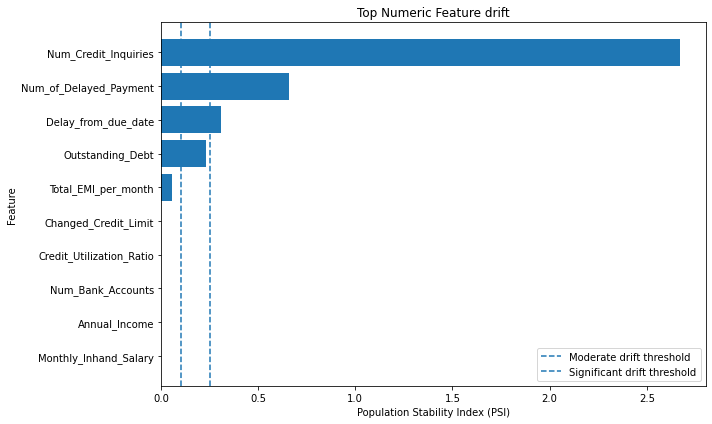

Saved: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\reports\numeric_feature_drift.png


In [28]:
# Create Monitoring Visualizations
# Numeric drift plot
import matplotlib.pyplot as plt

top_numeric = numeric_drift.head(10).sort_values("PSI")

plt.figure(figsize=(10, 6))
plt.barh(top_numeric["Feature"], top_numeric["PSI"])
plt.axvline(0.10, linestyle="--", label="Moderate drift threshold")
plt.axvline(0.25, linestyle="--", label="Significant drift threshold")

plt.xlabel("Population Stability Index (PSI)")
plt.ylabel("Feature")
plt.title("Top Numeric Feature drift")
plt.legend()
plt.tight_layout()

numeric_plot_path = REPORTS_DIR / "numeric_feature_drift.png"

plt.savefig(numeric_plot_path,dpi=150, bbox_inches="tight")

plt.show()

print("Saved:", numeric_plot_path)

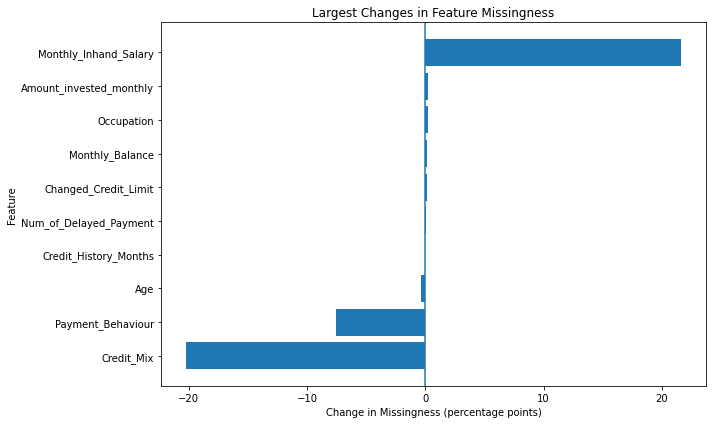

Saved: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\reports\missingness_drift.png


In [29]:
# Missingness drift plot
top_missingness = (
    missingness_drift
    .sort_values("Absolute_Change_pp", ascending=False).head(10).sort_values("Change_pp"))

plt.figure(figsize=(10, 6))

plt.barh(top_missingness["Feature"], top_missingness["Change_pp"])

plt.axvline(0, linestyle="-")

plt.xlabel("Change in Missingness (percentage points)")
plt.ylabel("Feature")
plt.title("Largest Changes in Feature Missingness")

plt.tight_layout()

missingness_plot_path = (
    REPORTS_DIR / "missingness_drift.png"
)

plt.savefig(missingness_plot_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved:", missingness_plot_path)

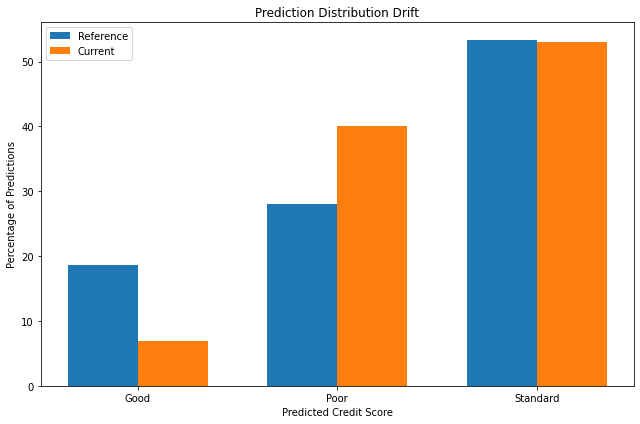

Saved: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\reports\prediction_distribution_drift.png


In [30]:
# Prediction Distribution
prediction_plot_data = prediction_drift["distribution"].copy()

x = np.arange(len(prediction_plot_data["Class"]))

width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width / 2, prediction_plot_data["Reference_%"], width, label="Reference")
plt.bar(x + width / 2, prediction_plot_data["Current_%"], width, label="Current")
plt.xticks(x, prediction_plot_data["Class"])
plt.ylabel("Percentage of Predictions")
plt.xlabel("Predicted Credit Score")
plt.title("Prediction Distribution Drift")
plt.legend()

plt.tight_layout()

prediction_plot_path = (REPORTS_DIR / "prediction_distribution_drift.png")

plt.savefig(prediction_plot_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved:", prediction_plot_path)

In [31]:
# create a human readable report

from datetime import datetime

significant_numeric = numeric_drift[numeric_drift["Interpretation"]=="Significant drift"]
moderate_numeric = numeric_drift[numeric_drift["Interpretation"]=="Moderate drift"]

significant_categorical = categorical_drift[categorical_drift["Interpretation"]=="Significant drift"]
moderate_categorical = categorical_drift[categorical_drift["Interpretation"]=="Moderate drift"]

significant_missingness = missingness_drift[missingness_drift["Interpretation"]=="Significant drift"]
moderate_missingness = missingness_drift[missingness_drift["Interpretation"]=="Moderate drift"]

report_text = f"""# Credit Score model monitoring report

## Monitoring Date
{datetime.now().strftime("%Y-%m-%d %H:%M")}

## Reference Population

The monitoring reference consists of the customer-level training populationused to train the final 
credit-score classification model.

- Rows: {len(monitoring_reference):,}
- Customers: {monitoring_reference["Customer_ID"].nunique():,}
- Numeric Features Monitored: {len(numeric_features)}
- Categorical Features Monitored: {len(categorical_features)}

## Monitoring Scenario

A synthetic production dataset was generated to validate the monitoring
framework. The simulated scenario introduced controlled changes in:

- Outstanding debt
- Total monthly EMI
- Credit inquiries
- Payment delays
- Credit mix distribution
- Payment behaviour distribution
- Missingness in Monthly Inhand Salary

The results below therefore demonstrate the ability of the monitoring
framework to detect known changes. They should not be interpreted as evidence
of actual production drift.

## 1. Numeric Feature Drift

Numeric drift was measured using Population Stability Index (PSI).

Interpretation:

- PSI < 0.10: No significant drift
- PSI 0.10–0.25: Moderate drift
- PSI >= 0.25: Significant drift

### Results

- Significant drift detected in {len(significant_numeric)} numeric features.
- Moderate drift detected in {len(moderate_numeric)} numeric features.

### Most affected features

{numeric_drift.head(10).to_string(index=False)}

## 2. Categorical Feature Drift

Categorical drift was measured using Total Variation Distance.

Interpretation:

- TV < 0.05: No significant drift
- TV 0.05–0.10: Moderate drift
- TV >= 0.10: Significant drift

### Results

- Significant drift detected in {len(significant_categorical)} categorical features.
- Moderate drift detected in {len(moderate_categorical)} categorical features.

### Results

{categorical_drift.to_string(index=False)}

## 3. Missingness Drift

Missingness was monitored separately because missing-value patterns can
change independently of feature distributions.

Interpretation:

- Absolute change < 5 percentage points: No significant drift
- 5–10 percentage points: Moderate drift
- >= 10 percentage points: Significant drift

### Results

- Significant missingness changes: {len(significant_missingness)}
- Moderate missingness changes: {len(moderate_missingness)}

### Most affected features

{missingness_drift.head(10).to_string(index=False)}

## 4. Prediction Drift

Prediction drift was measured using Total Variation Distance between the
reference and current prediction distributions.

- Prediction TV distance: {prediction_drift["tv_distance"]:.4f}
- Status: {prediction_drift["interpretation"]}

### Prediction distribution

{prediction_drift["distribution"].to_string(index=False)}

## 5. Overall Monitoring Summary

{monitoring_summary.to_string(index=False)}

## 6. Interpretation

The monitoring framework successfully identifies changes introduced in the
synthetic production population.

The strongest signals should be investigated before assuming that the model
itself has degraded. Feature drift may indicate a change in the incoming
customer population, data collection process, upstream systems, or business
processes.

Prediction drift provides an additional model-level signal. A meaningful
change in predicted credit-score categories can indicate that the population
being scored differs materially from the population used during training.

## 7. Recommended Production Actions

If similar drift were detected in a real production environment:

1. Investigate the affected features and upstream data sources.
2. Check whether changes are caused by genuine population shifts or data
   quality issues.
3. Monitor prediction distributions and confidence scores.
4. When actual customer outcomes become available, evaluate model
   performance using accuracy, macro F1, class-level recall and other
   appropriate metrics.
5. Retrain or recalibrate the model only after confirming that the observed
   change is persistent and meaningful.

## Limitations

This monitoring demonstration uses simulated production data because
historical production observations and post-deployment ground-truth labels
are not available.

Consequently, the current implementation demonstrates data and prediction
drift detection but does not establish real-world model performance
degradation.

## Monitoring Architecture

Reference training population
        |
        v
Feature distributions
        |
        +--> Numeric drift (PSI)
        |
        +--> Categorical drift (TV distance)
        |
        +--> Missingness drift
        |
        v
Production population
        |
        v
Model predictions
        |
        +--> Prediction distribution drift
        |
        v
Monitoring report
"""

report_path = REPORTS_DIR / "monitoring_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Monitoring report saved:")
print(report_path)


Monitoring report saved:
C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\reports\monitoring_report.md
